<a href="https://colab.research.google.com/github/Ishany0/Liver-disease-detection-using-ultrasound-imaging/blob/main/EfficientNetB0_and_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [84]:
path = kagglehub.dataset_download("mahendarbyra/behsof-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'behsof-dataset' dataset.
Path to dataset files: /kaggle/input/behsof-dataset


In [85]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "  " * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")
    if len(files) > 5:
        print(f"{subindent}... ({len(files)} files total)")

behsof-dataset/
  BEHSOF/
    NAFLD/
      nafld_957.jpg
      nafld_222.jpg
      nafld_1467.jpg
      nafld_1120.jpg
      nafld_678.jpg
      ... (1517 files total)
    Non-NAFLD/
      non_nafld_85.jpg
      non_nafld_77.jpg
      non_nafld_0.jpg
      non_nafld_2.jpg
      non_nafld_67.jpg
      ... (152 files total)


In [86]:
PREPROCESS_FUNC = tf.keras.applications.efficientnet.preprocess_input

In [87]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    zoom_range=0.1,
)

dev_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = dev_datagen

In [88]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img

aug_datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    zoom_range=0.1,
)

src_dir = "/content/BEHSOF_split/train/Non-NAFLD"
target_count = 1061
current_files = [f for f in os.listdir(src_dir) if f.endswith('.jpg')]
current_count = len(current_files)
needed = target_count - current_count

print(f"Currently {current_count} images, generating {needed} more...")

i = 0
while i < needed:
    fname = current_files[i % current_count]
    img = load_img(os.path.join(src_dir, fname), target_size=(256, 256))
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)
    for batch in aug_datagen.flow(x, batch_size=1):
        aug_img = array_to_img(batch[0])
        aug_img.save(os.path.join(src_dir, f"aug_{i}_{fname}"))
        i += 1
        break

print("Done. New count:", len(os.listdir(src_dir)))

Currently 1061 images, generating 0 more...
Done. New count: 1061


In [89]:
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

src = Path(path) / "BEHSOF"
out = Path("BEHSOF_split")

for cls in ['NAFLD','Non-NAFLD']:
  files = list((src/cls).glob('*.jpg'))
  train , temp = train_test_split(files , test_size = 0.3, random_state = 42)
  dev , test = train_test_split(temp, test_size = 0.5 , random_state = 42)
  for split , flist in zip(['train' , 'dev' , 'test'] , [train , dev , test]):
    d = out / split / cls
    d.mkdir(parents = True , exist_ok = True)
    for f in flist:
      shutil.copy(f,d / f.name)

print("Done: ", out.resolve())

Done:  /content/BEHSOF_split


In [90]:
import os
for split in ["train", "dev", "test"]:
    for cls in ["NAFLD", "Non-NAFLD"]:
        d = f"/content/BEHSOF_split/{split}/{cls}"
        print(split, cls, len(os.listdir(d)))

train NAFLD 1061
train Non-NAFLD 1061
dev NAFLD 228
dev Non-NAFLD 23
test NAFLD 228
test Non-NAFLD 23


In [91]:
IMG_SIZE = 224

train_dataset = train_datagen.flow_from_directory(
    "/content/BEHSOF_split/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
)

dev_dataset = dev_datagen.flow_from_directory(
    "/content/BEHSOF_split/dev",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
)

test_dataset = test_datagen.flow_from_directory(
    "/content/BEHSOF_split/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
)

Found 2122 images belonging to 2 classes.
Found 251 images belonging to 2 classes.
Found 251 images belonging to 2 classes.


In [92]:
class_weight_dict = {0: 1.0, 1: 1.0}
print(class_weight_dict)

{0: 1.0, 1: 1.0}


In [93]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout , GlobalAveragePooling2D , Conv2D , MaxPooling2D
from tensorflow.keras.regularizers import l2

eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
eff_base.trainable = False

model = Sequential([
    eff_base,
    Conv2D(64 , (2,2) , activation = 'relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    MaxPooling2D((2,2), padding='same'),
    Conv2D(64 , (2,2) , activation = 'relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    MaxPooling2D((2,2), padding='same'),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(64, activation='relu',kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

print(model.summary())

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 7, 7, 64)       │       327,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 4, 4, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,435,876 (16.92 MB)

 Trainable params: 386,049 (1.47 MB)

 Non-trainable params: 4,049,827 (15.45 MB)

None


In [94]:
class Early_Stopping_Callback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs=None):
    if logs['loss'] <0.01:
      print('\nLoss is low so cancelling training')
      self.model.stop_training = True


In [95]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=4, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', patience=3, factor=0.5, min_lr=1e-6)

In [96]:
from tensorflow.keras.metrics import Precision, Recall, AUC

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
    ]
)

In [97]:
EPOCHS_PHASE1 = 20

history = model.fit(train_dataset, epochs=EPOCHS, validation_data=dev_dataset , class_weight=class_weight_dict , callbacks=[Early_Stopping_Callback(), early_stop, reduce_lr])

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.8794 - auc: 0.9500 - loss: 0.3136 - precision: 0.8822 - recall: 0.8756 - val_accuracy: 0.9084 - val_auc: 0.8492 - val_loss: 0.3734 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.9453 - auc: 0.9851 - loss: 0.1726 - precision: 0.9530 - recall: 0.9369 - val_accuracy: 0.9124 - val_auc: 0.8615 - val_loss: 0.2749 - val_precision: 1.0000 - val_recall: 0.0435 - learning_rate: 0.0010
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.9581 - auc: 0.9928 - loss: 0.1274 - precision: 0.9576 - recall: 0.9585 - val_accuracy: 0.9163 - val_auc: 0.8873 - val_loss: 0.2430 - val_precision: 0.6000 - val_recall: 0.2609 - learning_rate: 0.0010
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.9599 - auc: 0.9927 - loss: 0.1241 - precision: 0.9683 - recall: 0.9510 - val_accuracy: 0.9243 - val_auc: 0.9171 - val_loss: 0.2372 -

In [98]:
eff_base.trainable = True
for layer in eff_base.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

early_stop_ft = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=3, restore_best_weights=True)
EPOCHS_PHASE2 = 10
history_finetune= model.fit(train_dataset, epochs=EPOCHS_PHASE2, validation_data=dev_dataset , class_weight=class_weight_dict , callbacks=[Early_Stopping_Callback(), early_stop_ft, reduce_lr])

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9632 - auc: 0.9946 - loss: 0.1108 - precision: 0.9522 - recall: 0.9755 - val_accuracy: 0.9442 - val_auc: 0.9692 - val_loss: 0.1742 - val_precision: 0.8462 - val_recall: 0.4783 - learning_rate: 1.0000e-05
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9717 - auc: 0.9950 - loss: 0.0938 - precision: 0.9708 - recall: 0.9727 - val_accuracy: 0.9482 - val_auc: 0.9683 - val_loss: 0.1915 - val_precision: 0.9167 - val_recall: 0.4783 - learning_rate: 1.0000e-05
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9760 - auc: 0.9969 - loss: 0.0864 - precision: 0.9755 - recall: 0.9764 - val_accuracy: 0.9522 - val_auc: 0.9477 - val_loss: 0.2090 - val_precision: 1.0000 - val_recall: 0.4783 - learning_rate: 1.0000e-05
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9722 - auc: 0.9958 - loss: 0.0929 - precision: 0.9726 - recall: 0.9717 - val_accuracy: 0.9482 - val_auc: 0.9104 - val_loss: 0.23

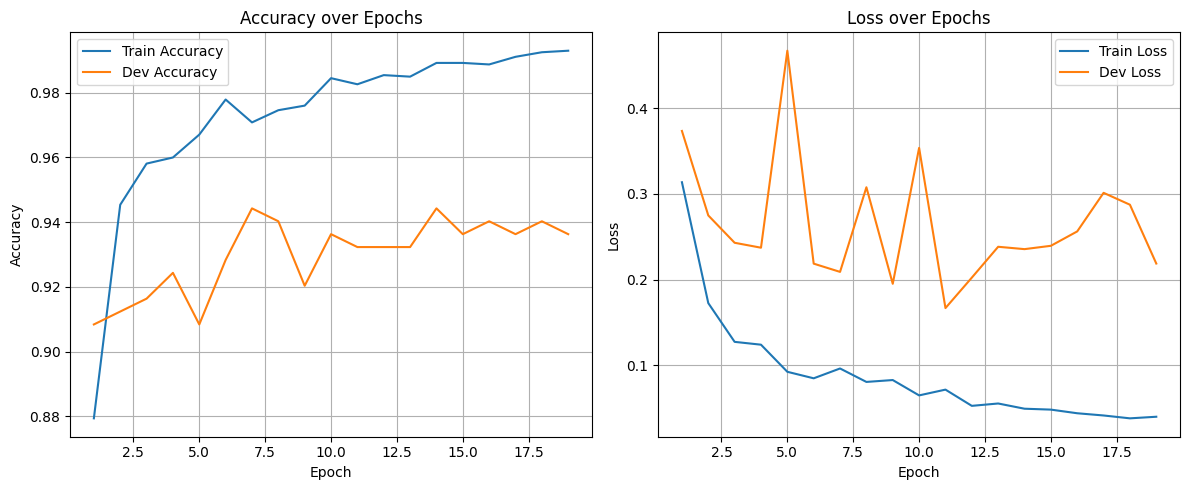

In [99]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Dev Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Dev Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [100]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

print("Evaluating on test dataset:")
results = model.evaluate(test_dataset)

y_dev_true = dev_dataset.classes
y_dev_prob = model.predict(dev_dataset).ravel()

from sklearn.metrics import f1_score
thresholds = np.linspace(0.01, 0.99, 99)
f1s = [f1_score(y_dev_true, (y_dev_prob >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1s)]
print(f"Best threshold (from dev): {best_threshold:.3f} | Best F1 (dev): {max(f1s):.3f}")

y_test_true = test_dataset.classes
y_test_prob = model.predict(test_dataset).ravel()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("\nClassification report (test, using dev-tuned threshold):")
print(classification_report(y_test_true, y_test_pred, target_names=['NAFLD', 'Non-NAFLD']))
print("AUC score:", roc_auc_score(y_test_true, y_test_prob))

Evaluating on test dataset:
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9641 - auc: 0.9600 - loss: 0.1548 - precision: 1.0000 - recall: 0.6087
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step
Best threshold (from dev): 0.030 | Best F1 (dev): 0.667
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step

Classification report (test, using dev-tuned threshold):
              precision    recall  f1-score   support

       NAFLD       0.99      0.91      0.95       228
   Non-NAFLD       0.49      0.87      0.62        23

    accuracy                           0.90       251
   macro avg       0.74      0.89      0.79       251
weighted avg       0.94      0.90      0.92       251

AUC score: 0.973493516399695


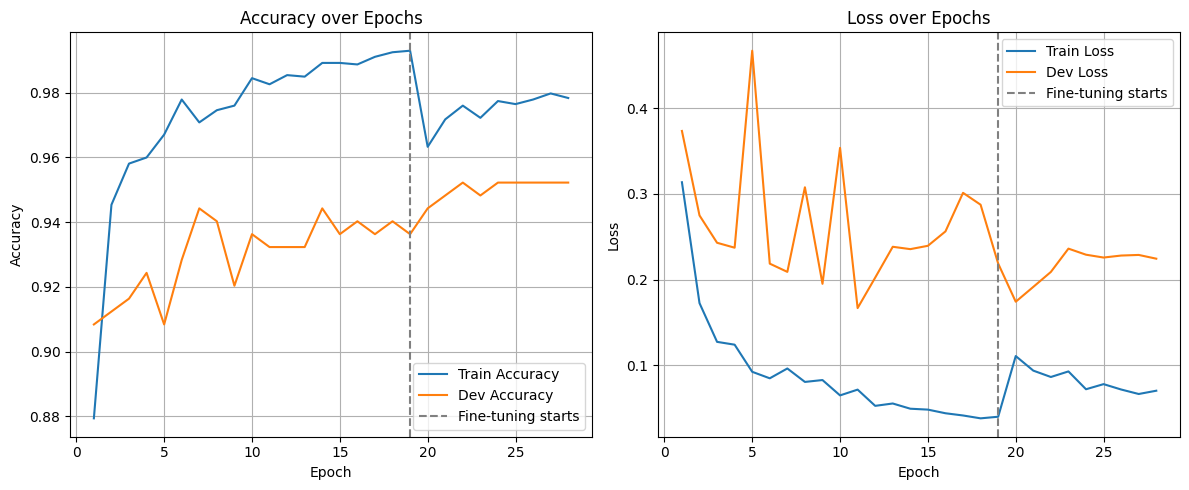

In [101]:
acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history.history['loss'] + history_finetune.history['loss']
val_loss = history.history['val_loss'] + history_finetune.history['val_loss']
epochs_range = range(1, len(acc) + 1)
finetune_start = len(history.history['accuracy'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Dev Accuracy')
plt.axvline(finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Accuracy over Epochs'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Dev Loss')
plt.axvline(finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Loss over Epochs'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()